# LiMatch diagnostic par chunk / scanner / cartographie spatiale

Ce notebook est adapté à la structure suivante :

- `chunks_root/`
  - `merged_1000_puck_vux/`
    - `chunkPair_A/`
      - `LiDAR_p2p_....txt`
    - `chunkPair_B/`
      - `LiDAR_p2p_....txt`
  - `merged_2000_puck_vux/`
    - `chunkPair_C/`
      - `LiDAR_p2p_....txt`

Autrement dit :
- le **chunk parent** est le dossier `merged_...`
- chaque sous-dossier contient une **paire de chunks**
- dans chaque dossier de paire, on trouve un fichier `LiDAR_p2p_*.txt`

Le notebook :
1. cherche automatiquement tous les fichiers `LiDAR_p2p_*.txt`,
2. reconstruit les métadonnées `chunk_parent` et `pair_dir`,
3. lit les correspondances,
4. fait les stats par type de paire scanner (`PUCK/PUCK`, `PUCK/VUX`, `VUX/VUX`),
5. fait les stats par chunk parent et par paire,
6. produit une cartographie spatiale 2D des bonnes / mauvaises zones.

> **Important** : il faut renseigner la cellule `CONFIG` en premier.

In [15]:

from pathlib import Path
import re
import json
import math
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import laspy
except ImportError:
    laspy = None

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## CONFIG

Renseigne ici :
- `chunks_root` : dossier qui contient `merged_1000_puck_vux`, `merged_2000_puck_vux`, ...
- les noms de colonnes du fichier `LiDAR_p2p`
- optionnellement les chemins des nuages merge si tu veux enrichir avec `scanner_src`

### Hypothèse de base
Le fichier LiDAR_p2p contient au minimum :
- coordonnées source : `x1,y1,z1`
- coordonnées target : `x2,y2,z2`

Et si possible aussi :
- `gps_time_1`, `gps_time_2` ou équivalent

Si tes noms de colonnes sont différents, adapte simplement la config.

In [44]:

# =========================
# CONFIG
# =========================
from pathlib import Path
chunks_root = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/navtools_PDM/limatch_optim/results_full_outage/iss_strict_only")

# Recherche récursive des fichiers de correspondances dans les sous-dossiers de paire
lidar_pattern = "LiDAR_p2p_chunk_*.txt"

# Séparateur du fichier LiDAR_p2p
lidar_sep = None  # None => auto via regex whitespace/comma ; sinon "," ou "\s+"

# Si header absent, mettre None et renseigner lidar_no_header_names
lidar_header = "infer"   # "infer" ou None
lidar_no_header_names = None

# Mapping des colonnes du fichier LiDAR_p2p
COLS = {
    "x1": "x1",
    "y1": "y1",
    "z1": "z1",
    "x2": "x2",
    "y2": "y2",
    "z2": "z2",
    # optionnel:
    "t1": None,          # ex: "gps_time_1"
    "t2": None,          # ex: "gps_time_2"
    "dist": None,        # si absent, sera recalculé
    "scanner1": None,    # si déjà présent dans le txt
    "scanner2": None,    # si déjà présent dans le txt
}

# =========================
# ENRICHISSEMENT SCANNER (optionnel)
# =========================
# Si le LiDAR_p2p ne contient pas scanner1/scanner2, tu peux fournir
# un ou plusieurs nuages merge (LAS/LAZ/TXT) avec gps_time + scanner_src
# pour reconstruire l'origine scanner des points de correspondance.
import re

merged_root = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_ODyN/merged")

def extract_number(p):
    m = re.search(r"merged_(\d+)_", p.name)
    return int(m.group(1)) if m else -1

merge_cloud_paths = sorted(
    merged_root.glob("merged_*_VUX_PUCK.las"),
    key=extract_number
)

# si tu veux seulement jusqu'à 11000
merge_cloud_paths = [p for p in merge_cloud_paths if extract_number(p) <= 28000]

print("Merged clouds utilisés:")
for p in merge_cloud_paths:
    print(p.name)

COLS = {
    "x1": "x1",
    "y1": "y1",
    "z1": "z1",
    "x2": "x2",
    "y2": "y2",
    "z2": "z2",
    "t1": None,
    "t2": None,
}
# Tolérance de matching spatio-temporel pour retrouver scanner_src
scanner_match_time_tol = 1e-6
scanner_match_xyz_tol = 1e-3

# =========================
# CARTOGRAPHIE SPATIALE
# =========================
grid_resolution = 5.0   # mètres
bad_quantile = 0.90     # seuil "mauvais" basé sur la distance
good_quantile = 0.10    # seuil "bon"

# Sauvegardes
output_dir = Path("./diagnostic_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

Merged clouds utilisés:
merged_1000_VUX_PUCK.las
merged_2000_VUX_PUCK.las
merged_3000_VUX_PUCK.las
merged_4000_VUX_PUCK.las
merged_5000_VUX_PUCK.las
merged_6000_VUX_PUCK.las
merged_7000_VUX_PUCK.las
merged_8000_VUX_PUCK.las
merged_9000_VUX_PUCK.las
merged_10000_VUX_PUCK.las
merged_11000_VUX_PUCK.las
merged_12000_VUX_PUCK.las
merged_13000_VUX_PUCK.las
merged_14000_VUX_PUCK.las
merged_15000_VUX_PUCK.las
merged_16000_VUX_PUCK.las
merged_17000_VUX_PUCK.las
merged_18000_VUX_PUCK.las
merged_19000_VUX_PUCK.las
merged_20000_VUX_PUCK.las
merged_21000_VUX_PUCK.las
merged_22000_VUX_PUCK.las
merged_23000_VUX_PUCK.las
merged_24000_VUX_PUCK.las
merged_25000_VUX_PUCK.las
merged_26000_VUX_PUCK.las
merged_27000_VUX_PUCK.las
merged_28000_VUX_PUCK.las


## Helpers

In [45]:

def scanner_code_to_label(v):
    # convention demandée:
    # 1 = PUCK, 2 = VUX
    if pd.isna(v):
        return np.nan
    try:
        iv = int(v)
    except Exception:
        return np.nan
    if iv == 1:
        return "PUCK"
    if iv == 2:
        return "VUX"
    return f"UNK_{iv}"

def pair_type_from_labels(a, b):
    if pd.isna(a) or pd.isna(b):
        return "UNKNOWN"
    s = sorted([str(a), str(b)])
    return "/".join(s)

def smart_read_table(path, sep=None, header="infer", names=None):
    if sep is None:
        # essaie csv puis whitespace
        try:
            return pd.read_csv(path, sep=",", header=header, names=names)
        except Exception:
            return pd.read_csv(path, sep=r"\s+", engine="python", header=header, names=names)
    return pd.read_csv(path, sep=sep, engine="python" if sep == r"\s+" else None, header=header, names=names)

def normalize_columns(df):
    df = df.copy()
    df.columns = ["t1", "t2", "x1", "y1", "z1", "x2", "y2", "z2"]
    return df

def ensure_required_columns(df, cols_map):
    required = ["x1","y1","z1","x2","y2","z2"]
    missing = []
    for k in required:
        c = cols_map.get(k)
        if c is None or c not in df.columns:
            missing.append((k,c))
    if missing:
        raise ValueError(f"Colonnes requises manquantes: {missing}")
    return True

def discover_lidar_files(chunks_root: Path, pattern: str):
    files = list(chunks_root.rglob("LiDAR_p2p*.txt"))
    rows = []
    for fp in files:
        rel = fp.relative_to(chunks_root)
        parts = rel.parts
        chunk_parent = parts[0] if len(parts) >= 1 else ""
        pair_dir = parts[-2] if len(parts) >= 2 else ""
        pair_rel_dir = str(rel.parent)
        rows.append({
            "lidar_p2p_path": str(fp),
            "chunk_parent": chunk_parent,
            "pair_dir": pair_dir,
            "pair_rel_dir": pair_rel_dir,
            "filename": fp.name,
        })
    return pd.DataFrame(rows)

def parse_pair_tokens(pair_name: str):
    # heuristiques légères
    # ex: cloud_3_4, pair_001_002, chunk_12__chunk_13 ...
    nums = re.findall(r'\d+', str(pair_name))
    out = {"pair_token_a": None, "pair_token_b": None}
    if len(nums) >= 2:
        out["pair_token_a"] = nums[-2]
        out["pair_token_b"] = nums[-1]
    return out

def compute_distance(df, cols):
    d = np.sqrt(
        (df[cols["x1"]].to_numpy() - df[cols["x2"]].to_numpy())**2 +
        (df[cols["y1"]].to_numpy() - df[cols["y2"]].to_numpy())**2 +
        (df[cols["z1"]].to_numpy() - df[cols["z2"]].to_numpy())**2
    )
    return d

def midpoint_columns(df, cols):
    mx = 0.5*(df[cols["x1"]].to_numpy() + df[cols["x2"]].to_numpy())
    my = 0.5*(df[cols["y1"]].to_numpy() + df[cols["y2"]].to_numpy())
    mz = 0.5*(df[cols["z1"]].to_numpy() + df[cols["z2"]].to_numpy())
    return mx, my, mz

## 1. Découverte des fichiers `LiDAR_p2p_*.txt`

In [46]:
from pathlib import Path
import pandas as pd

files = list(chunks_root.rglob("LiDAR_p2p_chunk*.txt"))

# optional: remove rsc files
files = [p for p in files if "rsc" not in p.name]

records = []

for p in files:
    parts = p.parts

    # merged folder
    merged_dir = next(x for x in parts if x.startswith("merged_"))

    # chunk pair folder
    chunk_pair = next(x for x in parts if "__" in x)

    chunk_a, chunk_b = chunk_pair.split("__")

    records.append({
        "lidar_p2p_path": str(p),
        "chunk_parent": merged_dir,
        "pair_dir": chunk_pair,
        "pair_rel_dir": str(p.parent),
        "pair_token_a": chunk_a,
        "pair_token_b": chunk_b
    })

files_df = pd.DataFrame(records)

print("Nb fichiers utilisés:", len(files_df))
display(files_df.head())

Nb fichiers utilisés: 202


,lidar_p2p_path,chunk_parent,pair_dir,pair_rel_dir,pair_token_a,pair_token_b
0,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,chunk_11016,chunk_12000
1,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11012__chunk_11013,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,chunk_11012,chunk_11013
2,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11000__chunk_11001,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,chunk_11000,chunk_11001
3,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11009__chunk_11010,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,chunk_11009,chunk_11010
4,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11002__chunk_11003,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,chunk_11002,chunk_11003


In [47]:
all_parts = []
failed = []

for i, row in files_df.iterrows():
    fp = Path(row["lidar_p2p_path"])
    try:
        # 🔥 lecture robuste (gère virgule + espaces)
        df = pd.read_csv(fp, sep=",\s*", engine="python", header=None)

        # ⚠️ ordre confirmé
        df.columns = ["t1", "t2", "x1", "y1", "z1", "x2", "y2", "z2"]

        # conversion numérique
        df = df.apply(pd.to_numeric, errors="coerce")

        # enlever lignes corrompues
        df = df.dropna()

        # distance
        df["p2p_dist"] = np.sqrt(
            (df["x1"] - df["x2"])**2 +
            (df["y1"] - df["y2"])**2 +
            (df["z1"] - df["z2"])**2
        )

        # midpoints (pour spatial map)
        df["mx"] = (df["x1"] + df["x2"]) / 2
        df["my"] = (df["y1"] + df["y2"]) / 2
        df["mz"] = (df["z1"] + df["z2"]) / 2

        # meta info
        df["lidar_p2p_path"] = str(fp)
        df["chunk_parent"] = row["chunk_parent"]
        df["pair_dir"] = row["pair_dir"]

        all_parts.append(df)

    except Exception as e:
        failed.append({"path": str(fp), "error": str(e)})

# afficher erreurs si besoin
if failed:
    print(f"{len(failed)} fichiers en échec")
    display(pd.DataFrame(failed).head())

# sécurité
if len(all_parts) == 0:
    raise ValueError("Aucune correspondance LiDAR_p2p trouvée")

# concat final
corr = pd.concat(all_parts, ignore_index=True)

print("Nb total de correspondances:", len(corr))
display(corr.head())

Nb total de correspondances: 234082


,t1,t2,x1,y1,z1,x2,y2,z2,p2p_dist,mx,my,mz,lidar_p2p_path,chunk_parent,pair_dir
0,305843.055719,305831.079387,-9.5602,-20.7904,-13.8757,23.1641,8.7387,-13.8265,44.077772,6.80195,-6.02585,-13.85110,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000
1,305843.055747,305831.484320,-9.6116,-19.2703,-12.2222,20.7719,8.3346,-11.9628,41.051856,5.58015,-5.46785,-12.09250,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000
2,305843.055933,305832.059134,-14.7099,-20.6327,-8.7981,21.5508,11.8443,-8.9482,48.678706,3.42045,-4.39420,-8.87315,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000
3,305843.060757,305832.464427,-6.7085,-12.8619,-8.2958,12.2617,4.1514,-8.2751,25.481784,2.77660,-4.35525,-8.28545,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000
4,305843.060980,305832.084116,-17.0378,-22.2219,-8.5177,23.4718,13.8196,-8.6750,54.222156,3.21700,-4.20115,-8.59635,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000


## 2. Lecture et concaténation de toutes les correspondances

In [48]:
import re
import numpy as np
import pandas as pd
import laspy
from pathlib import Path
from tqdm.auto import tqdm

def extract_num(name):
    m = re.search(r"merged_(\d+)_", name)
    return int(m.group(1)) if m else None

def nearest_match_scanner(times, gps_sorted, scanner_sorted, tol=1e-6):
    pos = np.searchsorted(gps_sorted, times)

    out = np.full(len(times), np.nan)

    left_ok = pos > 0
    right_ok = pos < len(gps_sorted)

    left_idx = np.clip(pos - 1, 0, len(gps_sorted) - 1)
    right_idx = np.clip(pos, 0, len(gps_sorted) - 1)

    dleft = np.full(len(times), np.inf)
    dright = np.full(len(times), np.inf)

    dleft[left_ok] = np.abs(times[left_ok] - gps_sorted[left_idx[left_ok]])
    dright[right_ok] = np.abs(times[right_ok] - gps_sorted[right_idx[right_ok]])

    choose_left = dleft <= dright
    best_idx = np.where(choose_left, left_idx, right_idx)
    best_dist = np.where(choose_left, dleft, dright)

    ok = best_dist <= tol
    out[ok] = scanner_sorted[best_idx[ok]]
    return out

# index des merged
merged_map = {Path(p).stem: str(p) for p in merge_cloud_paths}

# cache léger
las_cache = {}

def load_las_minimal(merged_name):
    if merged_name in las_cache:
        return las_cache[merged_name]

    las = laspy.read(merged_map[merged_name])
    gps = np.asarray(las["gps_time"])
    scanner = np.asarray(las["scanner_src"])

    order = np.argsort(gps)
    gps_sorted = gps[order]
    scanner_sorted = scanner[order]

    las_cache[merged_name] = (gps_sorted, scanner_sorted)
    return gps_sorted, scanner_sorted

corr["scanner1_code"] = np.nan
corr["scanner2_code"] = np.nan

tol = 1e-6
groups = corr.groupby("chunk_parent").groups

for chunk_parent, idx in tqdm(groups.items(), total=len(groups), desc="Assign scanner with neighbor fallback"):
    if chunk_parent not in merged_map:
        continue

    cur_num = extract_num(chunk_parent)
    current_candidates = [
        f"merged_{cur_num-1000}_VUX_PUCK",
        f"merged_{cur_num}_VUX_PUCK",
        f"merged_{cur_num+1000}_VUX_PUCK",
    ]
    candidates = [c for c in current_candidates if c in merged_map]

    t1_vals = corr.loc[idx, "t1"].to_numpy()
    t2_vals = corr.loc[idx, "t2"].to_numpy()

    s1 = np.full(len(t1_vals), np.nan)
    s2 = np.full(len(t2_vals), np.nan)

    # scanner1: current first, then neighbors if needed
    for cand in [f"merged_{cur_num}_VUX_PUCK"] + [c for c in candidates if c != f"merged_{cur_num}_VUX_PUCK"]:
        if cand not in merged_map:
            continue
        gps_sorted, scanner_sorted = load_las_minimal(cand)
        missing = np.isnan(s1)
        if not np.any(missing):
            break
        s1_try = nearest_match_scanner(t1_vals[missing], gps_sorted, scanner_sorted, tol=tol)
        tmp = s1[missing].copy()
        fill = ~np.isnan(s1_try)
        tmp[fill] = s1_try[fill]
        s1[missing] = tmp

    # scanner2: same logic, but this is where fallback matters most
    for cand in [f"merged_{cur_num}_VUX_PUCK"] + [c for c in candidates if c != f"merged_{cur_num}_VUX_PUCK"]:
        if cand not in merged_map:
            continue
        gps_sorted, scanner_sorted = load_las_minimal(cand)
        missing = np.isnan(s2)
        if not np.any(missing):
            break
        s2_try = nearest_match_scanner(t2_vals[missing], gps_sorted, scanner_sorted, tol=tol)
        tmp = s2[missing].copy()
        fill = ~np.isnan(s2_try)
        tmp[fill] = s2_try[fill]
        s2[missing] = tmp

    corr.loc[idx, "scanner1_code"] = s1
    corr.loc[idx, "scanner2_code"] = s2

scanner_code_to_label = {1: "PUCK", 2: "VUX"}

corr["scanner1"] = corr["scanner1_code"].map(scanner_code_to_label)
corr["scanner2"] = corr["scanner2_code"].map(scanner_code_to_label)
corr["pair_type"] = corr["scanner1"].fillna("UNK") + "/" + corr["scanner2"].fillna("UNK")

print("scanner1 NaN:", corr["scanner1_code"].isna().sum())
print("scanner2 NaN:", corr["scanner2_code"].isna().sum())
print(corr["pair_type"].value_counts())

Assign scanner with neighbor fallback:   0%|          | 0/19 [00:00<?, ?it/s]

scanner1 NaN: 0
scanner2 NaN: 0
pair_type
VUX/VUX      123637
PUCK/VUX      47095
VUX/PUCK      42755
PUCK/PUCK     20595
Name: count, dtype: int64


In [49]:
# =========================================
# SAVE enriched correspondences (safe parquet)
# =========================================

corr_save = corr.copy()

# enlever / convertir les colonnes non supportées par parquet
for col in corr_save.columns:
    if str(corr_save[col].dtype).startswith("interval"):
        corr_save[col] = corr_save[col].astype(str)
    elif str(corr_save[col].dtype) == "category":
        corr_save[col] = corr_save[col].astype(str)

save_path = output_dir / "corr_enriched_with_scanners_3.parquet"
corr_save.to_parquet(save_path, index=False)

print("Fichier sauvegardé :", save_path)
print("Taille :", save_path.stat().st_size / 1e6, "MB")

Fichier sauvegardé : diagnostic_outputs/corr_enriched_with_scanners_3.parquet
Taille : 19.776211 MB


In [50]:
# =========================================
# LOAD enriched correspondences
# =========================================

load_path = output_dir / "corr_enriched_with_scanners_3.parquet"

corr = pd.read_parquet(load_path)

print("Fichier rechargé :", load_path)
print("Nb correspondances :", len(corr))
display(corr.head())

Fichier rechargé : diagnostic_outputs/corr_enriched_with_scanners_3.parquet
Nb correspondances : 234082


,t1,t2,x1,y1,z1,x2,y2,z2,p2p_dist,mx,my,mz,lidar_p2p_path,chunk_parent,pair_dir,scanner1_code,scanner2_code,scanner1,scanner2,pair_type
0,305843.055719,305831.079387,-9.5602,-20.7904,-13.8757,23.1641,8.7387,-13.8265,44.077772,6.80195,-6.02585,-13.85110,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000,2.0,2.0,VUX,VUX,VUX/VUX
1,305843.055747,305831.484320,-9.6116,-19.2703,-12.2222,20.7719,8.3346,-11.9628,41.051856,5.58015,-5.46785,-12.09250,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000,2.0,2.0,VUX,VUX,VUX/VUX
2,305843.055933,305832.059134,-14.7099,-20.6327,-8.7981,21.5508,11.8443,-8.9482,48.678706,3.42045,-4.39420,-8.87315,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000,2.0,2.0,VUX,VUX,VUX/VUX
3,305843.060757,305832.464427,-6.7085,-12.8619,-8.2958,12.2617,4.1514,-8.2751,25.481784,2.77660,-4.35525,-8.28545,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000,2.0,2.0,VUX,VUX,VUX/VUX
4,305843.060980,305832.084116,-17.0378,-22.2219,-8.5177,23.4718,13.8196,-8.6750,54.222156,3.21700,-4.20115,-8.59635,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,merged_11000_VUX_PUCK,chunk_11016__chunk_12000,2.0,2.0,VUX,VUX,VUX/VUX


## Load trajectory

In [51]:
from lib.trajectory import Trajectory

trj_cfg = {
    "timeRef": "GPS"
}

trj = Trajectory.fromSBET(
    "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/out/ODyN_GNSS_INS.out",
    trj_cfg
)

print("Trajectory loaded:", len(trj.time))

Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/out/ODyN_GNSS_INS.out
Trajectory loaded: 39900


In [52]:
from lib.rotations import quatMult

trj.estimate_q_l2e(interp=False)

for i in range(len(trj.q)):
    trj.q[i] = quatMult(trj.q_l2e[i], trj.q[i])

In [53]:
import numpy as np
from lib.rotations import quat2dcm
from tqdm.auto import tqdm
from pyproj import Transformer
# on travaille sur une copie légère si besoin
# corr = corr.copy()

# interpolation de la trajectoire aux temps des correspondances
t1 = corr["t1"].to_numpy(dtype=np.float64)
t2 = corr["t2"].to_numpy(dtype=np.float64)

_, ecef1, q1 = trj.interp(t1, updateSelf=False)
_, ecef2, q2 = trj.interp(t2, updateSelf=False)

# vecteurs locaux des correspondances
v1 = corr[["x1", "y1", "z1"]].to_numpy(dtype=np.float64)
v2 = corr[["x2", "y2", "z2"]].to_numpy(dtype=np.float64)

# sortie
P1_ecef = np.empty_like(v1)
P2_ecef = np.empty_like(v2)

# géoréférencement point par point
for i in tqdm(range(len(corr)), desc="Georeferencing LiDAR correspondences"):
    R1 = quat2dcm(q1[i])
    R2 = quat2dcm(q2[i])

    # hypothèse : v1/v2 déjà en body frame
    P1_ecef[i] = R1 @ v1[i] + ecef1[i]
    P2_ecef[i] = R2 @ v2[i] + ecef2[i]

ecef2lv95 = Transformer.from_crs("EPSG:4978", "EPSG:2056", always_xy=True)
x1_map, y1_map, z1_map = ecef2lv95.transform(
    P1_ecef[:, 0], P1_ecef[:, 1], P1_ecef[:, 2]
)
x2_map, y2_map, z2_map = ecef2lv95.transform(
    P2_ecef[:, 0], P2_ecef[:, 1], P2_ecef[:, 2]
)

P1_map = np.column_stack((x1_map, y1_map, z1_map))
P2_map = np.column_stack((x2_map, y2_map, z2_map))
dxyz_map = P1_map - P2_map

corr["dx_map"] = dxyz_map[:, 0]
corr["dy_map"] = dxyz_map[:, 1]
corr["dz_map"] = dxyz_map[:, 2]

corr["p2p_dist_map"] = np.linalg.norm(dxyz_map, axis=1)
corr["p2p_dist_xy_map"] = np.linalg.norm(dxyz_map[:, :2], axis=1)

# garder aussi les coords géoréférencées si utile
corr["x1_map"] = x1_map
corr["y1_map"] = y1_map
corr["z1_map"] = z1_map

corr["x2_map"] = x2_map
corr["y2_map"] = y2_map
corr["z2_map"] = z2_map

# milieu des correspondances (utile pour les cartes spatiales)
corr["xm_map"] = 0.5 * (corr["x1_map"] + corr["x2_map"])
corr["ym_map"] = 0.5 * (corr["y1_map"] + corr["y2_map"])
corr["zm_map"] = 0.5 * (corr["z1_map"] + corr["z2_map"])

print(corr["p2p_dist_map"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
display(
    corr[
        [
            "t1", "t2",
            "p2p_dist_map", "p2p_dist_xy_map",
            "scanner1", "scanner2",
            "chunk_parent", "pair_dir"
        ]
    ].head()
)

Georeferencing LiDAR correspondences:   0%|          | 0/234082 [00:00<?, ?it/s]

count    234082.000000
mean          0.028155
std           0.041073
min           0.000309
50%           0.017675
90%           0.046092
95%           0.096084
99%           0.204271
max           2.615644
Name: p2p_dist_map, dtype: float64


,t1,t2,p2p_dist_map,p2p_dist_xy_map,scanner1,scanner2,chunk_parent,pair_dir
0,305843.055719,305831.079387,0.021748,0.015977,VUX,VUX,merged_11000_VUX_PUCK,chunk_11016__chunk_12000
1,305843.055747,305831.484320,0.017386,0.013024,VUX,VUX,merged_11000_VUX_PUCK,chunk_11016__chunk_12000
2,305843.055933,305832.059134,0.018628,0.013744,VUX,VUX,merged_11000_VUX_PUCK,chunk_11016__chunk_12000
3,305843.060757,305832.464427,0.018402,0.015155,VUX,VUX,merged_11000_VUX_PUCK,chunk_11016__chunk_12000
4,305843.060980,305832.084116,0.025359,0.017045,VUX,VUX,merged_11000_VUX_PUCK,chunk_11016__chunk_12000


## Statistiques par corr (scanner)

=== VUX/VUX ===


,quantile_bin,count,min,max,mean,median,std
0,Q1,12364,0.000309,0.009830,0.007635,0.008096,0.001812
1,Q2,12364,0.009830,0.012099,0.011048,0.011085,0.000649
2,Q3,12363,0.012099,0.013777,0.012963,0.012971,0.000481
3,Q4,12364,0.013777,0.015300,0.014544,0.014544,0.000436
4,Q5,12364,0.015301,0.016918,0.016102,0.016095,0.000469
5,Q6,12363,0.016918,0.018772,0.017817,0.017801,0.000531
6,Q7,12364,0.018772,0.021096,0.019900,0.019885,0.000671
7,Q8,12363,0.021096,0.024156,0.022476,0.022395,0.000868
8,Q9,12364,0.024156,0.036902,0.028202,0.027246,0.003363
9,Q10,12364,0.036904,2.610704,0.086081,0.055803,0.071739


=== PUCK/PUCK ===


,quantile_bin,count,min,max,mean,median,std
0,Q1,2060,0.000655,0.009046,0.006378,0.006696,0.001888
1,Q2,2059,0.009049,0.012540,0.010892,0.010928,0.000996
2,Q3,2060,0.012541,0.015510,0.014026,0.014031,0.000857
3,Q4,2059,0.015511,0.018570,0.017020,0.016999,0.000884
4,Q5,2060,0.018572,0.021708,0.020140,0.020145,0.000892
5,Q6,2059,0.021710,0.025619,0.023571,0.023544,0.001115
6,Q7,2059,0.025621,0.032006,0.028417,0.028236,0.001827
7,Q8,2060,0.032006,0.043477,0.037230,0.037094,0.003306
8,Q9,2059,0.043480,0.092375,0.060868,0.057372,0.013749
9,Q10,2060,0.092388,2.615644,0.167015,0.147895,0.096831


=== VUX/PUCK ===


,quantile_bin,count,min,max,mean,median,std
0,Q1,8985,0.000453,0.008599,0.006243,0.006574,0.001731
1,Q2,8985,0.008599,0.011459,0.010131,0.010184,0.000825
2,Q3,8985,0.011460,0.013737,0.012612,0.012610,0.000656
3,Q4,8985,0.013737,0.015968,0.014841,0.014828,0.000643
4,Q5,8985,0.015968,0.018466,0.017182,0.017163,0.000721
5,Q6,8985,0.018466,0.021525,0.019953,0.019940,0.000881
6,Q7,8985,0.021525,0.025696,0.023418,0.023311,0.001190
7,Q8,8985,0.025696,0.034219,0.029410,0.029065,0.002453
8,Q9,8985,0.034220,0.059069,0.043270,0.041960,0.006607
9,Q10,8985,0.059075,2.179889,0.142259,0.123323,0.091086


=== Counts ===


,pair_type,count
0,VUX/VUX,123637
1,VUX/PUCK,89850
2,PUCK/PUCK,20595


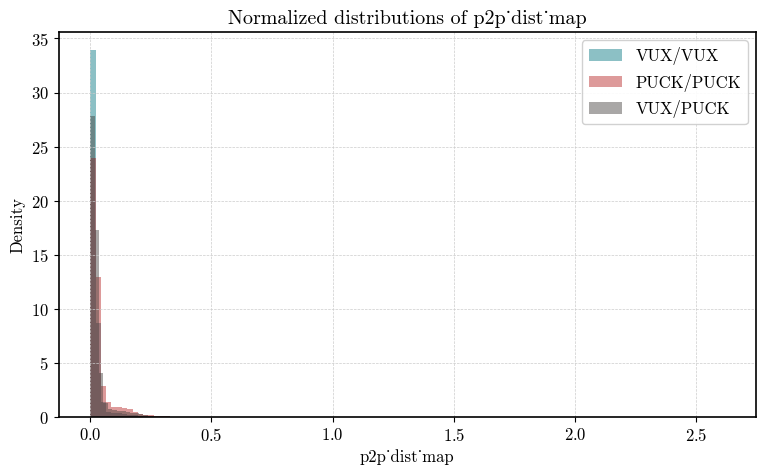

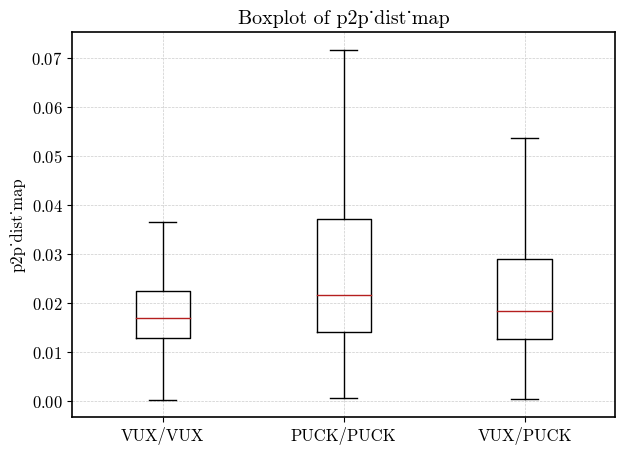

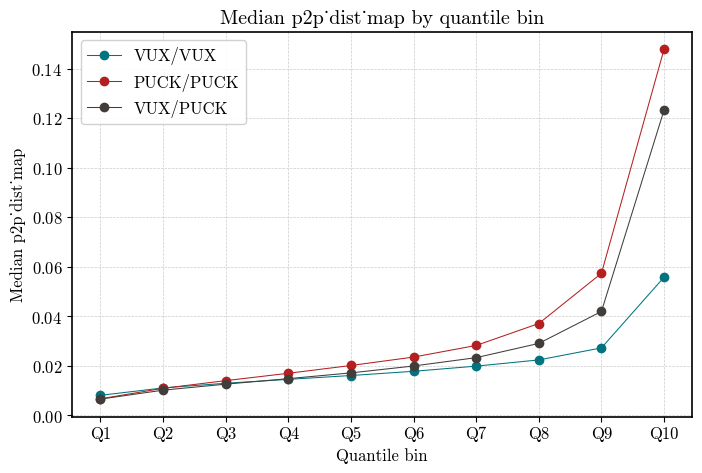

=== Summary stats ===


,pair_type,count,mean,median,p95
0,VUX/VUX,123637,0.023677,0.016918,0.055802
1,PUCK/PUCK,20595,0.038558,0.021708,0.147889
2,VUX/PUCK,89850,0.031932,0.018466,0.123312


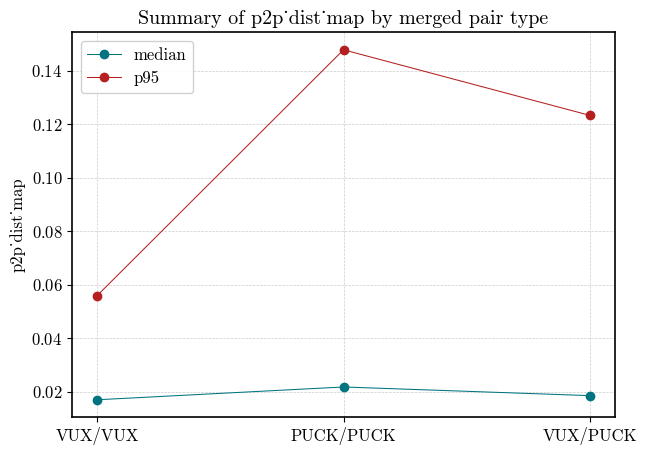

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
value_col = "p2p_dist_map"
n_quantiles = 10
n_plot_max = 200000  # subsampling for hist/boxplot if needed

# ============================================================
# CLASSIFY PAIRS
# ============================================================
def classify_pair(row):
    s1 = row["scanner1"]
    s2 = row["scanner2"]

    if s1 == "VUX" and s2 == "VUX":
        return "VUX/VUX"
    elif s1 == "PUCK" and s2 == "PUCK":
        return "PUCK/PUCK"
    elif {s1, s2} == {"VUX", "PUCK"}:
        return "VUX/PUCK"
    else:
        return "OTHER"

corr["pair_type_merged"] = corr.apply(classify_pair, axis=1)

# ============================================================
# HELPERS
# ============================================================
def make_quantile_table(df, value_col="p2p_dist_map", n_quantiles=10):
    df = df.copy()
    if len(df) == 0:
        return pd.DataFrame()

    q_labels = [f"Q{i+1}" for i in range(n_quantiles)]

    df["quantile_bin"] = pd.qcut(
        df[value_col],
        q=n_quantiles,
        labels=q_labels,
        duplicates="drop"
    )

    out = df.groupby("quantile_bin")[value_col].agg(
        count="count",
        min="min",
        max="max",
        mean="mean",
        median="median",
        std="std"
    ).reset_index()

    return out

def subsample_series(s, n_max=200000, seed=0):
    s = s.dropna()
    if len(s) <= n_max:
        return s
    return s.sample(n=n_max, random_state=seed)

# ============================================================
# DATAFRAMES
# ============================================================
df_vux_vux = corr[corr["pair_type_merged"] == "VUX/VUX"].copy()
df_puck_puck = corr[corr["pair_type_merged"] == "PUCK/PUCK"].copy()
df_vux_puck = corr[corr["pair_type_merged"] == "VUX/PUCK"].copy()

# ============================================================
# TABLES
# ============================================================
table_vux_vux = make_quantile_table(df_vux_vux, value_col=value_col, n_quantiles=n_quantiles)
table_puck_puck = make_quantile_table(df_puck_puck, value_col=value_col, n_quantiles=n_quantiles)
table_vux_puck = make_quantile_table(df_vux_puck, value_col=value_col, n_quantiles=n_quantiles)

print("=== VUX/VUX ===")
display(table_vux_vux)

print("=== PUCK/PUCK ===")
display(table_puck_puck)

print("=== VUX/PUCK ===")
display(table_vux_puck)

# ============================================================
# COUNTS
# ============================================================
summary_counts = (
    corr["pair_type_merged"]
    .value_counts()
    .rename_axis("pair_type")
    .reset_index(name="count")
)
print("=== Counts ===")
display(summary_counts)

# ============================================================
# PREP FOR PLOTS
# ============================================================
s_vux_vux = subsample_series(df_vux_vux[value_col], n_plot_max)
s_puck_puck = subsample_series(df_puck_puck[value_col], n_plot_max)
s_vux_puck = subsample_series(df_vux_puck[value_col], n_plot_max)

plot_data = []
plot_labels = []

if len(s_vux_vux) > 0:
    plot_data.append(s_vux_vux.values)
    plot_labels.append("VUX/VUX")
if len(s_puck_puck) > 0:
    plot_data.append(s_puck_puck.values)
    plot_labels.append("PUCK/PUCK")
if len(s_vux_puck) > 0:
    plot_data.append(s_vux_puck.values)
    plot_labels.append("VUX/PUCK")

# ============================================================
# PLOT 1 — NORMALIZED HISTOGRAMS
# ============================================================
plt.figure(figsize=(9, 5))

if len(s_vux_vux) > 0:
    plt.hist(s_vux_vux, bins=120, density=True, alpha=0.45, label="VUX/VUX")
if len(s_puck_puck) > 0:
    plt.hist(s_puck_puck, bins=120, density=True, alpha=0.45, label="PUCK/PUCK")
if len(s_vux_puck) > 0:
    plt.hist(s_vux_puck, bins=120, density=True, alpha=0.45, label="VUX/PUCK")

plt.xlabel(value_col)
plt.ylabel("Density")
plt.title(f"Normalized distributions of {value_col}")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# PLOT 2 — BOXPLOT
# ============================================================
plt.figure(figsize=(7, 5))
plt.boxplot(plot_data, labels=plot_labels, showfliers=False)
plt.ylabel(value_col)
plt.title(f"Boxplot of {value_col}")
plt.grid(True)
plt.show()

# ============================================================
# PLOT 3 — MEDIAN BY QUANTILE
# ============================================================
plt.figure(figsize=(8, 5))

if len(table_vux_vux) > 0:
    plt.plot(table_vux_vux["quantile_bin"], table_vux_vux["median"], marker="o", label="VUX/VUX")
if len(table_puck_puck) > 0:
    plt.plot(table_puck_puck["quantile_bin"], table_puck_puck["median"], marker="o", label="PUCK/PUCK")
if len(table_vux_puck) > 0:
    plt.plot(table_vux_puck["quantile_bin"], table_vux_puck["median"], marker="o", label="VUX/PUCK")

plt.xlabel("Quantile bin")
plt.ylabel(f"Median {value_col}")
plt.title(f"Median {value_col} by quantile bin")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# PLOT 4 — P95 / MEAN SUMMARY
# ============================================================
summary_stats = pd.DataFrame([
    {
        "pair_type": "VUX/VUX",
        "count": len(df_vux_vux),
        "mean": df_vux_vux[value_col].mean() if len(df_vux_vux) else np.nan,
        "median": df_vux_vux[value_col].median() if len(df_vux_vux) else np.nan,
        "p95": df_vux_vux[value_col].quantile(0.95) if len(df_vux_vux) else np.nan,
    },
    {
        "pair_type": "PUCK/PUCK",
        "count": len(df_puck_puck),
        "mean": df_puck_puck[value_col].mean() if len(df_puck_puck) else np.nan,
        "median": df_puck_puck[value_col].median() if len(df_puck_puck) else np.nan,
        "p95": df_puck_puck[value_col].quantile(0.95) if len(df_puck_puck) else np.nan,
    },
    {
        "pair_type": "VUX/PUCK",
        "count": len(df_vux_puck),
        "mean": df_vux_puck[value_col].mean() if len(df_vux_puck) else np.nan,
        "median": df_vux_puck[value_col].median() if len(df_vux_puck) else np.nan,
        "p95": df_vux_puck[value_col].quantile(0.95) if len(df_vux_puck) else np.nan,
    },
])

print("=== Summary stats ===")
display(summary_stats)

plt.figure(figsize=(7, 5))
plt.plot(summary_stats["pair_type"], summary_stats["median"], marker="o", label="median")
plt.plot(summary_stats["pair_type"], summary_stats["p95"], marker="o", label="p95")
plt.ylabel(value_col)
plt.title(f"Summary of {value_col} by merged pair type")
plt.grid(True)
plt.legend()
plt.show()

## garder Q90

In [64]:
from pathlib import Path
import numpy as np

# ============================================================
# CONFIG
# ============================================================
chunks_root = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/navtools_PDM/limatch_optim/results_full_outage/iss_strict_only")
out_file = chunks_root / "LiDAR_p2p_q90.txt"

# ============================================================
# FILTER ON p2p_dist_map
# keep Q1..Q9 = remove worst 10%
# ============================================================
q90_thresh = corr["p2p_dist_map"].quantile(0.90)

mask_q90 = corr["p2p_dist_map"] <= q90_thresh
corr_q90 = corr.loc[mask_q90].copy()

print(f"Total correspondences      : {len(corr)}")
print(f"Q90 threshold [m]         : {q90_thresh:.6f}")
print(f"Kept correspondences      : {len(corr_q90)}")
print(f"Removed correspondences   : {len(corr) - len(corr_q90)}")

# ============================================================
# WRITE OUTPUT
# assumes these columns are the original LiDAR_p2p columns
# ============================================================
cols_out = ["t1", "t2", "x1", "y1", "z1", "x2", "y2", "z2"]

corr_q90[cols_out].to_csv(
    out_file,
    index=False,
    header=False,
    float_format="%.6f"
)

print(f"Written: {out_file}")

Total correspondences      : 234082
Q90 threshold [m]         : 0.046092
Kept correspondences      : 210673
Removed correspondences   : 23409
Written: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/navtools_PDM/limatch_optim/results_full_outage/iss_strict_only/LiDAR_p2p_q90.txt


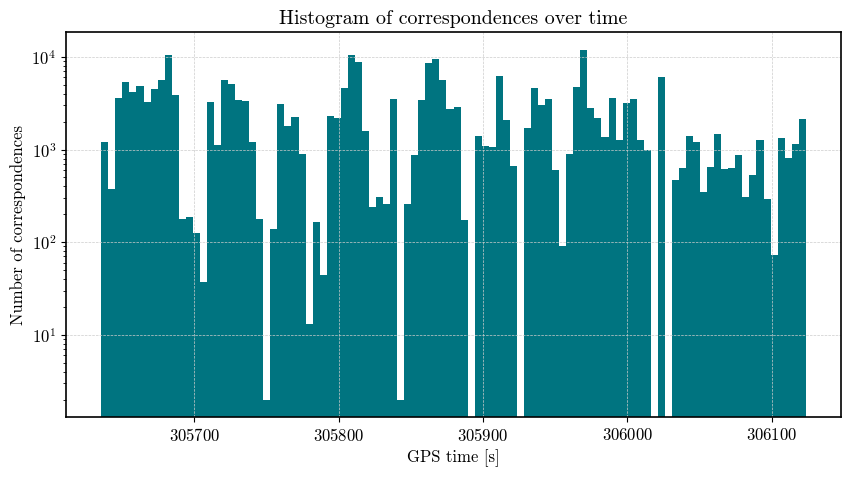

Nb total de sous-dossiers de paires : 238
Nb avec LiDAR_p2p_chunk : 202
Nb sans LiDAR_p2p_chunk : 36
Success rate : 84.87%


In [67]:
import numpy as np
import matplotlib.pyplot as plt

# temps représentatif de chaque correspondance
corr["t_mid"] = 0.5 * (corr["t1"] + corr["t2"])

plt.figure(figsize=(10, 5))
plt.hist(corr["t_mid"].dropna(), bins=100)
plt.yscale('log')
plt.xlabel("GPS time [s]")
plt.ylabel("Number of correspondences")
plt.title("Histogram of correspondences over time")
plt.grid(True)
plt.show()

# Racine LiMatch
limatch_root = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/navtools_PDM/limatch_optim/results_full_outage/iss_strict_only")

# Tous les sous-dossiers de paires de chunks, ex: merged_xxx/.../chunk_A__chunk_B
pair_dirs = []
for merged_dir in limatch_root.iterdir():
    if not merged_dir.is_dir():
        continue
    if not merged_dir.name.startswith("merged_"):
        continue

    for sub in merged_dir.iterdir():
        if sub.is_dir() and "__" in sub.name:
            pair_dirs.append(sub)

rows = []

for pair_dir in pair_dirs:
    # on cherche seulement le vrai fichier LiDAR_p2p_chunk_...
    p2p_files = list(pair_dir.glob("cor_outputs/LiDAR_p2p_chunk_*.txt"))

    rows.append({
        "merged_parent": pair_dir.parent.name,
        "pair_dir": pair_dir.name,
        "pair_path": str(pair_dir),
        "has_p2p": len(p2p_files) > 0,
        "n_p2p_files": len(p2p_files),
        "p2p_file": str(p2p_files[0]) if len(p2p_files) > 0 else None,
    })

success_df = pd.DataFrame(rows)

n_total = len(success_df)
n_success = int(success_df["has_p2p"].sum())
n_fail = n_total - n_success
success_rate = 100 * n_success / n_total if n_total > 0 else 0.0

print(f"Nb total de sous-dossiers de paires : {n_total}")
print(f"Nb avec LiDAR_p2p_chunk : {n_success}")
print(f"Nb sans LiDAR_p2p_chunk : {n_fail}")
print(f"Success rate : {success_rate:.2f}%")


## Get max dist

In [96]:
idx_max = corr["p2p_dist_map"].idxmax()
row_max = corr.loc[idx_max]

print("Index :", idx_max)
display(row_max.to_frame().T)

Index : 1609


,t1,t2,x1,y1,z1,x2,y2,z2,p2p_dist,mx,my,mz,lidar_p2p_path,chunk_parent,pair_dir,scanner1_code,scanner2_code,scanner1,scanner2,pair_type,dx_map,dy_map,dz_map,p2p_dist_map,p2p_dist_xy_map,x1_map,y1_map,z1_map,x2_map,y2_map,z2_map,xm_map,ym_map,zm_map
1609,305639.855309,305639.428621,5.3604,14.1124,4.7935,9.1849,13.9114,5.1537,3.84668,7.27265,14.0119,4.9736,/media/b085164/Elements/CALIB_26_02_25/georef_...,merged_3000_VUX_PUCK,chunk_3004__chunk_3005,1.0,2.0,PUCK,VUX,PUCK/VUX,-2.361183,-1.640468,0.354397,2.896881,2.875121,2543470.690792,1157778.021282,911.887993,2543473.051975,1157779.66175,911.533596,2543471.871383,1157778.841516,911.710795


In [10]:
percentiles = np.arange(0.0, 1.01, 0.1)  # 0%,10%,...,100%

rows = []

for pair, group in corr.groupby("pair_type"):
    q = group["p2p_dist_map"].quantile(percentiles)
    
    row = {"pair_type": pair}
    for p, val in zip(percentiles, q.values):
        row[f"p{int(p*100)}"] = val
    
    rows.append(row)

df_pair_percentiles = pd.DataFrame(rows)

display(df_pair_percentiles.sort_values("p50"))

,pair_type,p0,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100
2,VUX/PUCK,0.000366,0.005235,0.007144,0.008922,0.010926,0.013273,0.016139,0.019778,0.028194,0.095464,0.759492
3,VUX/VUX,0.000309,0.008974,0.010856,0.012157,0.013228,0.014255,0.015302,0.016647,0.018813,0.023202,1.773598
1,PUCK/VUX,0.001115,0.007975,0.010083,0.011720,0.013219,0.014669,0.016348,0.018602,0.021806,0.032764,0.559770
0,PUCK/PUCK,0.000808,0.006277,0.008491,0.010476,0.012981,0.015611,0.018757,0.024097,0.039890,0.126307,0.813807


## 4. Diagnostics globaux

### Puck seulement

### Tout sauf VUX/VUX

# Plots

In [99]:
from pyproj import Transformer
import numpy as np
import pandas as pd

# ECEF -> LV95
ecef_to_lv95 = Transformer.from_crs("EPSG:4978", "EPSG:2056", always_xy=True)

# P1_ecef et P2_ecef viennent de ta cellule de géoréférencement
x1_map, y1_map, z1_map = ecef_to_lv95.transform(P1_ecef[:, 0], P1_ecef[:, 1], P1_ecef[:, 2])
x2_map, y2_map, z2_map = ecef_to_lv95.transform(P2_ecef[:, 0], P2_ecef[:, 1], P2_ecef[:, 2])

corr["x1_map"] = x1_map
corr["y1_map"] = y1_map
corr["z1_map"] = z1_map

corr["x2_map"] = x2_map
corr["y2_map"] = y2_map
corr["z2_map"] = z2_map

# milieu spatial de la correspondance
corr["xm_map"] = 0.5 * (corr["x1_map"] + corr["x2_map"])
corr["ym_map"] = 0.5 * (corr["y1_map"] + corr["y2_map"])
corr["zm_map"] = 0.5 * (corr["z1_map"] + corr["z2_map"])

display(corr[["xm_map", "ym_map", "p2p_dist_map"]].head())
print(len(corr))

,xm_map,ym_map,p2p_dist_map
0,2.543558e+06,1.157792e+06,0.144045
1,2.543553e+06,1.157795e+06,0.024731
2,2.543553e+06,1.157795e+06,0.029486
3,2.543554e+06,1.157797e+06,0.021440
4,2.543552e+06,1.157795e+06,0.019513


303101


In [102]:
grid_res = 10.0  # mètres

corr["ix"] = np.floor(corr["xm_map"] / grid_res).astype(int)
corr["iy"] = np.floor(corr["ym_map"] / grid_res).astype(int)

spatial_stats = corr.groupby(["ix", "iy"]).agg(
    n_corr=("p2p_dist_map", "size"),
    p50=("p2p_dist_map", "median"),
    p90=("p2p_dist_map", lambda s: s.quantile(0.90)),
    p95=("p2p_dist_map", lambda s: s.quantile(0.95)),
    mean=("p2p_dist_map", "mean"),
).reset_index()

# centre des cellules
spatial_stats["x"] = (spatial_stats["ix"] + 0.5) * grid_res
spatial_stats["y"] = (spatial_stats["iy"] + 0.5) * grid_res

display(spatial_stats.head())

,ix,iy,n_corr,p50,p90,p95,mean,x,y
0,254214,115687,73,0.032785,0.133314,0.174038,0.056950,2542145.0,1156875.0
1,254214,115688,282,0.028673,0.055910,0.112283,0.038919,2542145.0,1156885.0
2,254214,115689,112,0.030280,0.118675,0.148382,0.047293,2542145.0,1156895.0
3,254215,115685,1,0.054936,0.054936,0.054936,0.054936,2542155.0,1156855.0
4,254215,115686,207,0.015461,0.101156,0.125347,0.039643,2542155.0,1156865.0


In [103]:
import plotly.graph_objects as go
from pyproj import Transformer

# --------------------------------------------------
# LV95 -> WGS84
# --------------------------------------------------
to_wgs84 = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)

plot_df = spatial_stats.dropna(subset=["x", "y", "n_corr"]).copy()

lon, lat = to_wgs84.transform(plot_df["x"].values, plot_df["y"].values)
plot_df["lon"] = lon
plot_df["lat"] = lat

# centre carte
center_lat = float(plot_df["lat"].mean())
center_lon = float(plot_df["lon"].mean())

fig = go.Figure()

fig.add_trace(go.Scattermapbox(
    lon=plot_df["lon"],
    lat=plot_df["lat"],
    mode="markers",
    marker=dict(
        size=8,  # taille FIXE
        color=plot_df["n_corr"],
        colorscale="Viridis",
        colorbar=dict(title="Nombre de correspondances"),
        opacity=0.85,
    ),
    hoverinfo="text",
    text=[
        f"n_corr = {n}<br>"
        f"p50 = {p50:.3f} m<br>"
        f"p90 = {p90:.3f} m<br>"
        f"p95 = {p95:.3f} m"
        for n, p50, p90, p95 in zip(
            plot_df["n_corr"],
            plot_df["p50"],
            plot_df["p90"],
            plot_df["p95"],
        )
    ],
    name="Correspondences"
))

fig.update_layout(
    title="Densité spatiale des correspondances",
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=16,
    ),
    width=1000,
    height=800,
    margin=dict(l=10, r=10, t=50, b=10),
)

fig.show()

/tmp/ipykernel_2549740/2702077924.py:21: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [104]:
import plotly.graph_objects as go
from pyproj import Transformer

# --------------------------------------------------
# LV95 -> WGS84
# --------------------------------------------------
to_wgs84 = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)

plot_df = spatial_stats.dropna(subset=["x", "y", "p50"]).copy()

lon, lat = to_wgs84.transform(plot_df["x"].values, plot_df["y"].values)
plot_df["lon"] = lon
plot_df["lat"] = lat

# centre carte
center_lat = float(plot_df["lat"].mean())
center_lon = float(plot_df["lon"].mean())

fig = go.Figure()

fig.add_trace(go.Scattermapbox(
    lon=plot_df["lon"],
    lat=plot_df["lat"],
    mode="markers",
    marker=dict(
        size=8,                   # taille fixe
        color=plot_df["p50"],     # couleur = distance médiane
        colorscale="Turbo",
        colorbar=dict(title="Distance médiane [m]"),
        opacity=0.85,
    ),
    hoverinfo="text",
    text=[
        f"p50 = {p50:.3f} m<br>"
        f"p90 = {p90:.3f} m<br>"
        f"p95 = {p95:.3f} m<br>"
        f"n_corr = {n}"
        for p50, p90, p95, n in zip(
            plot_df["p50"],
            plot_df["p90"],
            plot_df["p95"],
            plot_df["n_corr"],
        )
    ],
    name="Correspondences"
))

fig.update_layout(
    title="Distance entre correspondances — carte spatiale (p50)",
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=16,
    ),
    width=1000,
    height=800,
    margin=dict(l=10, r=10, t=50, b=10),
)

fig.show()

/tmp/ipykernel_2549740/898316055.py:21: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



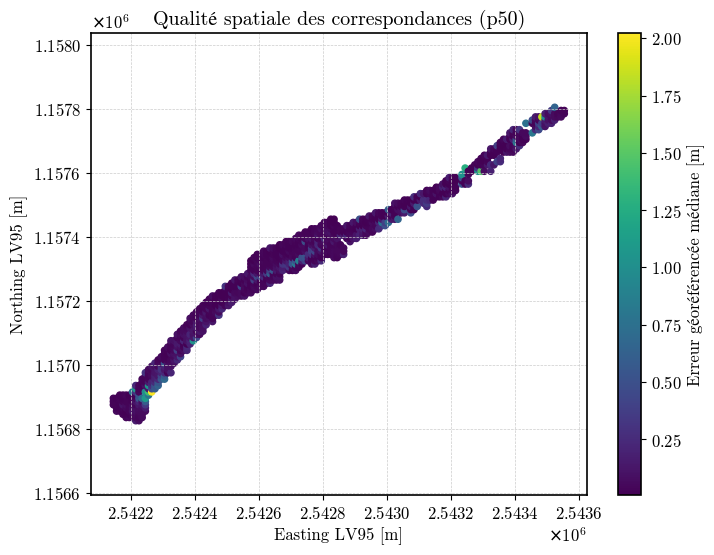

In [105]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    spatial_stats["x"],
    spatial_stats["y"],
    c=spatial_stats["p50"],
    s=20,
)
plt.colorbar(sc, label="Erreur géoréférencée médiane [m]")
plt.xlabel("Easting LV95 [m]")
plt.ylabel("Northing LV95 [m]")
plt.title("Qualité spatiale des correspondances (p50)")
plt.axis("equal")
plt.grid(True)
plt.show()

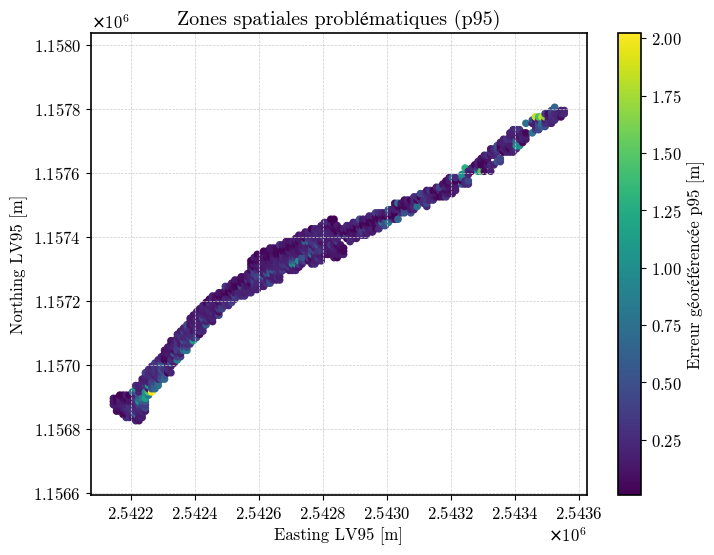

In [106]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    spatial_stats["x"],
    spatial_stats["y"],
    c=spatial_stats["p95"],
    s=20,
)
plt.colorbar(sc, label="Erreur géoréférencée p95 [m]")
plt.xlabel("Easting LV95 [m]")
plt.ylabel("Northing LV95 [m]")
plt.title("Zones spatiales problématiques (p95)")
plt.axis("equal")
plt.grid(True)
plt.show()

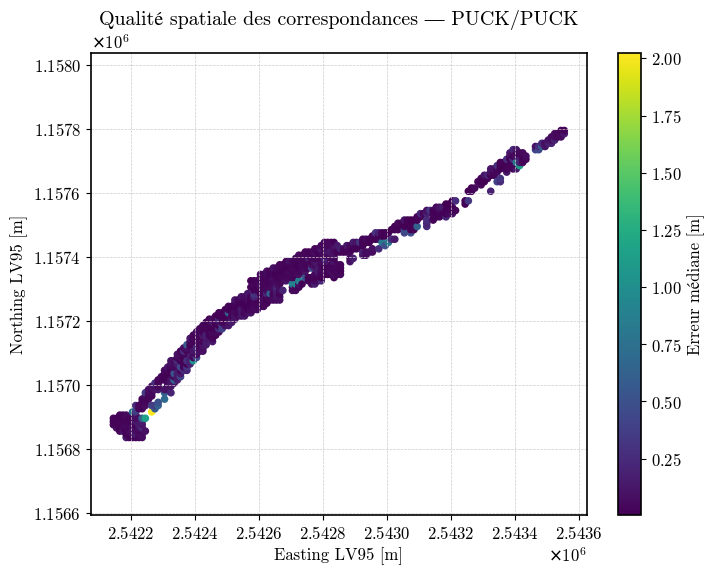

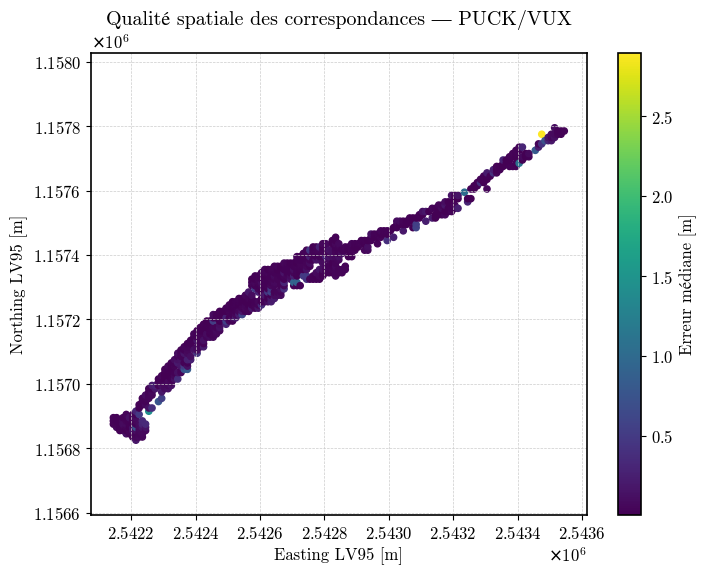

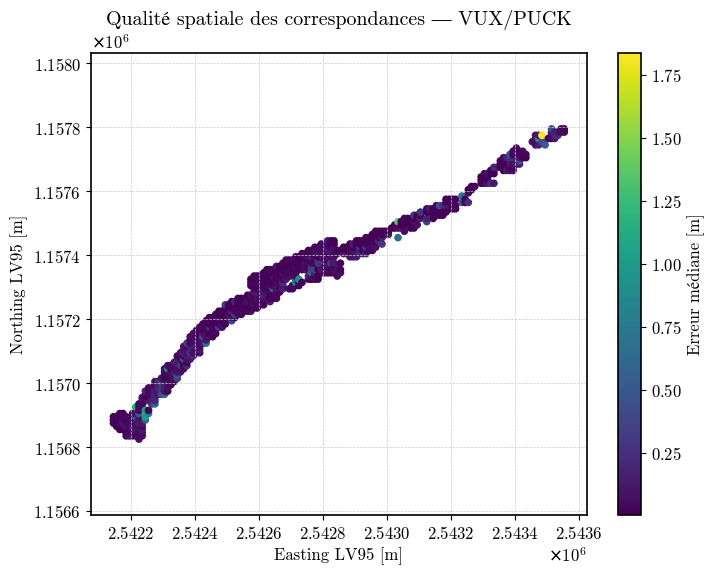

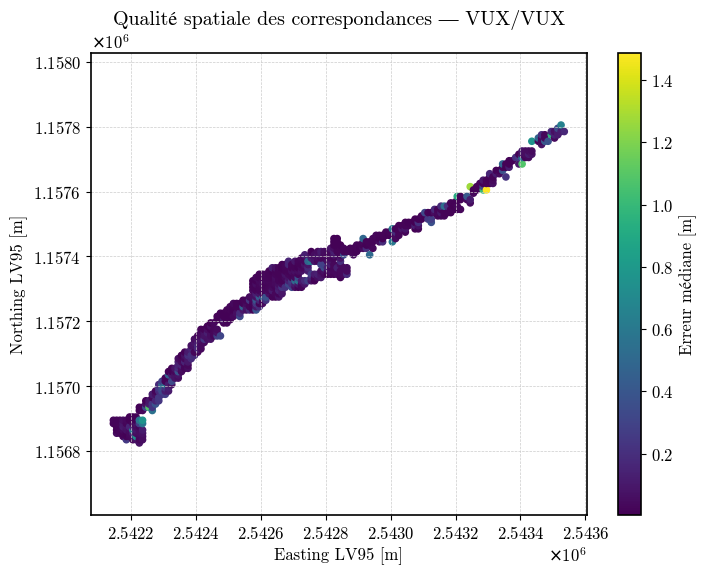

In [108]:
for pair_type in ["PUCK/PUCK", "PUCK/VUX", "VUX/PUCK", "VUX/VUX"]:
    sub = corr[corr["pair_type"] == pair_type].copy()
    if len(sub) == 0:
        continue

    sub["ix"] = np.floor(sub["xm_map"] / grid_res).astype(int)
    sub["iy"] = np.floor(sub["ym_map"] / grid_res).astype(int)

    ss = sub.groupby(["ix", "iy"]).agg(
        n_corr=("p2p_dist_map", "size"),
        p50=("p2p_dist_map", "median"),
    ).reset_index()

    ss["x"] = (ss["ix"] + 0.5) * grid_res
    ss["y"] = (ss["iy"] + 0.5) * grid_res

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        ss["x"],
        ss["y"],
        c=ss["p50"],
        s=20,
    )
    plt.colorbar(sc, label="Erreur médiane [m]")
    plt.xlabel("Easting LV95 [m]")
    plt.ylabel("Northing LV95 [m]")
    plt.title(f"Qualité spatiale des correspondances — {pair_type}")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

In [115]:
from lib.trajectory import *
from lib.rotations import *
import numpy as np
import yaml

def load_config(path):
    with open(path, 'r') as f:
        return yaml.safe_load(f)
# chargement config YAML
cfg = load_config("/home/b085164/PDM_Romain_Defferrard/navtools/configs/compareCalibOutage_v2.yml")

reference_traj = load_trajectory(cfg['reference'])
target_trajs = [load_trajectory(traj) for traj in cfg['targets']]

t_plot = np.arange(
    cfg['t_interp']['start'],
    cfg['t_interp']['stop'],
    1 / cfg['t_interp']['freq']
)

# interp reference
reference_traj.interp(t_plot)
reference_traj.estimate_q_l2e()

# interp targets
for traj in target_trajs:
    traj.interp(t_plot)
    traj.estimate_q_l2e()

Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage/ref_full_GNSS/reference.out
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage/chunks_VUX_PUCK/2EMEzone/out/ODyN.tar.gz


In [116]:
from pyproj import Transformer

ecef_to_lv95 = Transformer.from_crs("EPSG:4978", "EPSG:2056", always_xy=True)

# reference
ref_ecef = reference_traj.ecef_interp

# projection ref
ref_x, ref_y, ref_z = ecef_to_lv95.transform(
    ref_ecef[:,0], ref_ecef[:,1], ref_ecef[:,2]
)

results = []

for traj, cfg_traj in zip(target_trajs, cfg["targets"]):
    name = cfg_traj["label"]
    
    ecef = traj.ecef_interp
    
    # erreur ECEF
    err = np.linalg.norm(ecef - ref_ecef, axis=1)
    
    # projection LV95
    x, y, z = ecef_to_lv95.transform(ecef[:,0], ecef[:,1], ecef[:,2])
    
    df = pd.DataFrame({
        "x": x,
        "y": y,
        "error": err,
        "label": name
    })
    
    results.append(df)

traj_df = pd.concat(results, ignore_index=True)

display(traj_df.head())

,x,y,error,label
0,2.543482e+06,1.157768e+06,0.008282,ODyN | VUX+PUCK chunks
1,2.543479e+06,1.157766e+06,0.008490,ODyN | VUX+PUCK chunks
2,2.543477e+06,1.157764e+06,0.008715,ODyN | VUX+PUCK chunks
3,2.543474e+06,1.157762e+06,0.008929,ODyN | VUX+PUCK chunks
4,2.543472e+06,1.157761e+06,0.009170,ODyN | VUX+PUCK chunks


In [117]:
grid_res = 2.0

traj_df["ix"] = np.floor(traj_df["x"] / grid_res).astype(int)
traj_df["iy"] = np.floor(traj_df["y"] / grid_res).astype(int)

spatial_traj = traj_df.groupby(["label", "ix", "iy"]).agg(
    n=("error", "size"),
    p50=("error", "median"),
    p90=("error", lambda s: s.quantile(0.9)),
    mean=("error", "mean")
).reset_index()

spatial_traj["x"] = (spatial_traj["ix"] + 0.5) * grid_res
spatial_traj["y"] = (spatial_traj["iy"] + 0.5) * grid_res

In [118]:
import numpy as np
import plotly.graph_objects as go

for label in spatial_traj["label"].unique():
    sub = spatial_traj[spatial_traj["label"] == label].copy()
    sub = sub.dropna(subset=["x", "y", "p50"])

    if len(sub) == 0:
        continue

    cmin = np.nanmin(sub["p50"].values)
    cmax = np.nanmax(sub["p50"].values)

    if not np.isfinite(cmin):
        cmin = 0.0
    if not np.isfinite(cmax) or cmax == cmin:
        cmax = cmin + 1.0

    fig = go.Figure()

    fig.add_trace(go.Scattergl(
        x=sub["x"],
        y=sub["y"],
        mode="markers",
        marker=dict(
            size=7,
            color=sub["p50"],
            colorscale="Viridis",
            cmin=cmin,
            cmax=cmax,
            colorbar=dict(title="Erreur médiane [m]"),
            opacity=0.85,
        ),
        text=[
            f"x = {x:.2f}<br>"
            f"y = {y:.2f}<br>"
            f"p50 = {p50:.3f} m<br>"
            f"p90 = {p90:.3f} m<br>"
            f"mean = {mean:.3f} m<br>"
            f"n = {n}"
            for x, y, p50, p90, mean, n in zip(
                sub["x"],
                sub["y"],
                sub["p50"],
                sub["p90"],
                sub["mean"],
                sub["n"],
            )
        ],
        hoverinfo="text",
    ))

    fig.update_layout(
        title=label,
        xaxis_title="Easting LV95 [m]",
        yaxis_title="Northing LV95 [m]",
        width=900,
        height=700,
    )

    fig.update_yaxes(
        scaleanchor="x",
        scaleratio=1
    )

    fig.show()

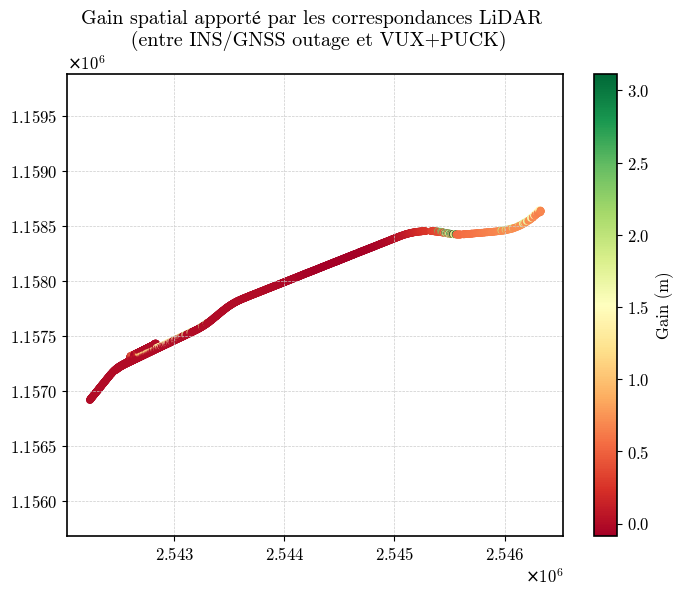

In [106]:
# pivot pour comparer deux trajs
pivot = spatial_traj.pivot_table(
    index=["ix", "iy"],
    columns="label",
    values="p50"
).reset_index()

# exemple: GNSS vs VUX+PUCK
pivot["gain"] = pivot["ODyN | INS/GNSS"] - pivot["ODyN | VUX+PUCK chunks"]

pivot["x"] = (pivot["ix"] + 0.5) * grid_res
pivot["y"] = (pivot["iy"] + 0.5) * grid_res

plt.figure(figsize=(8,6))
sc = plt.scatter(
    pivot["x"], pivot["y"],
    c=pivot["gain"],
    s=20,
    cmap="RdYlGn"
)
plt.colorbar(sc, label="Gain (m)")
plt.title("Gain spatial apporté par les correspondances LiDAR \n (entre INS/GNSS outage et VUX+PUCK)")
plt.axis("equal")
plt.grid(True)
plt.show()

In [107]:
import numpy as np
import plotly.graph_objects as go

# pivot pour comparer deux trajs
pivot = spatial_traj.pivot_table(
    index=["ix", "iy"],
    columns="label",
    values="p50"
).reset_index()

# exemple: GNSS vs VUX+PUCK
pivot["gain"] = pivot["ODyN | INS/GNSS"] - pivot["ODyN | VUX+PUCK chunks"]

pivot["x"] = (pivot["ix"] + 0.5) * grid_res
pivot["y"] = (pivot["iy"] + 0.5) * grid_res

# enlever les NaN
pivot_plot = pivot.dropna(subset=["gain", "x", "y"]).copy()

# échelle couleur symétrique autour de 0
cmax = np.nanmax(np.abs(pivot_plot["gain"].values))
if not np.isfinite(cmax) or cmax == 0:
    cmax = 1.0

fig = go.Figure()

fig.add_trace(go.Scattergl(
    x=pivot_plot["x"],
    y=pivot_plot["y"],
    mode="markers",
    marker=dict(
        size=7,
        color=pivot_plot["gain"],
        colorscale="RdYlGn",
        cmin=-cmax,
        cmax=cmax,
        colorbar=dict(title="Gain (m)"),
        opacity=0.85,
    ),
    text=[
        f"x = {x:.2f}<br>"
        f"y = {y:.2f}<br>"
        f"gain = {g:.3f} m<br>"
        f"ix = {ix}<br>"
        f"iy = {iy}"
        for x, y, g, ix, iy in zip(
            pivot_plot["x"],
            pivot_plot["y"],
            pivot_plot["gain"],
            pivot_plot["ix"],
            pivot_plot["iy"],
        )
    ],
    hoverinfo="text",
))

fig.update_layout(
    title="Gain spatial apporté par les correspondances LiDAR<br>(entre INS/GNSS outage et VUX+PUCK)",
    xaxis_title="Easting LV95 [m]",
    yaxis_title="Northing LV95 [m]",
    width=900,
    height=700,
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1
)

fig.show()

Maintenant comment améliorer encore la trajectoire?

- Tester chunks 10m ?

- Fine tuning ?

## Success rate

In [65]:
from pathlib import Path
import pandas as pd

# Racine LiMatch
limatch_root = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/navtools_PDM/limatch_optim/results_full_outage/iss_strict_only")

# Tous les sous-dossiers de paires de chunks, ex: merged_xxx/.../chunk_A__chunk_B
pair_dirs = []
for merged_dir in limatch_root.iterdir():
    if not merged_dir.is_dir():
        continue
    if not merged_dir.name.startswith("merged_"):
        continue

    for sub in merged_dir.iterdir():
        if sub.is_dir() and "__" in sub.name:
            pair_dirs.append(sub)

rows = []

for pair_dir in pair_dirs:
    # on cherche seulement le vrai fichier LiDAR_p2p_chunk_...
    p2p_files = list(pair_dir.glob("cor_outputs/LiDAR_p2p_chunk_*.txt"))

    rows.append({
        "merged_parent": pair_dir.parent.name,
        "pair_dir": pair_dir.name,
        "pair_path": str(pair_dir),
        "has_p2p": len(p2p_files) > 0,
        "n_p2p_files": len(p2p_files),
        "p2p_file": str(p2p_files[0]) if len(p2p_files) > 0 else None,
    })

success_df = pd.DataFrame(rows)

n_total = len(success_df)
n_success = int(success_df["has_p2p"].sum())
n_fail = n_total - n_success
success_rate = 100 * n_success / n_total if n_total > 0 else 0.0

print(f"Nb total de sous-dossiers de paires : {n_total}")
print(f"Nb avec LiDAR_p2p_chunk : {n_success}")
print(f"Nb sans LiDAR_p2p_chunk : {n_fail}")
print(f"Success rate : {success_rate:.2f}%")

display(success_df.head())

Nb total de sous-dossiers de paires : 238
Nb avec LiDAR_p2p_chunk : 202
Nb sans LiDAR_p2p_chunk : 36
Success rate : 84.87%


,merged_parent,pair_dir,pair_path,has_p2p,n_p2p_files,p2p_file
0,merged_11000_VUX_PUCK,chunk_11016__chunk_12000,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,True,1,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...
1,merged_11000_VUX_PUCK,chunk_11012__chunk_11013,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,True,1,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...
2,merged_11000_VUX_PUCK,chunk_11000__chunk_11001,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,True,1,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...
3,merged_11000_VUX_PUCK,chunk_11009__chunk_11010,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,True,1,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...
4,merged_11000_VUX_PUCK,chunk_11002__chunk_11003,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...,True,1,/home/b085164/PDM_Romain_Defferrard/ESO-PDM/na...


## Estimer résidus statique env. 305380s

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
gps_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/in/GPS.txt")

# borne grossière que tu as donnée
t0_guess = 305380.0
t1_guess = 305430.0

# adapte si besoin
sep = r"\s+|,"
header = None

# si ton fichier n'a pas d'en-tête
col_names = ["t", "x", "y", "z"]

# seuil vitesse pour considérer "statique"
# à ajuster selon le bruit GPS : commence avec 0.03 à 0.10 m/s
static_speed_thresh = 0.05

# durée minimale d'un segment statique pour être retenu
min_static_duration = 5.0  # secondes


# ============================================================
# LOAD GPS
# ============================================================
gps = pd.read_csv(gps_path, sep=sep, engine="python", header=header)
gps = gps.iloc[:, :4].copy()
gps.columns = col_names

for c in ["t", "x", "y", "z"]:
    gps[c] = pd.to_numeric(gps[c], errors="coerce")

gps = gps.dropna().sort_values("t").reset_index(drop=True)

# ============================================================
# CROP TO ROUGH WINDOW
# ============================================================
sub = gps[(gps["t"] >= t0_guess) & (gps["t"] <= t1_guess)].copy().reset_index(drop=True)

if len(sub) < 3:
    raise ValueError("Pas assez de points GPS dans la fenêtre donnée.")

# ============================================================
# COMPUTE APPARENT SPEED
# ============================================================
dt = np.diff(sub["t"].values)
dx = np.diff(sub["x"].values)
dy = np.diff(sub["y"].values)
dz = np.diff(sub["z"].values)

dist3d = np.sqrt(dx**2 + dy**2 + dz**2)
speed = np.full(len(sub), np.nan)
speed[1:] = dist3d / dt

sub["speed"] = speed

# ============================================================
# FIND LONGEST STATIC SEGMENT
# ============================================================
is_static = sub["speed"].fillna(0.0) <= static_speed_thresh
sub["is_static"] = is_static

segments = []
start_idx = None

for i, flag in enumerate(is_static):
    if flag and start_idx is None:
        start_idx = i
    elif not flag and start_idx is not None:
        end_idx = i - 1
        segments.append((start_idx, end_idx))
        start_idx = None

if start_idx is not None:
    segments.append((start_idx, len(sub) - 1))

# garder seulement les segments assez longs
valid_segments = []
for i0, i1 in segments:
    dur = sub.loc[i1, "t"] - sub.loc[i0, "t"]
    if dur >= min_static_duration:
        valid_segments.append((i0, i1, dur))

if not valid_segments:
    raise ValueError("Aucun segment statique assez long trouvé. Essaie d'augmenter le seuil de vitesse.")

# prendre le plus long
best_i0, best_i1, best_dur = max(valid_segments, key=lambda x: x[2])
static_section = sub.loc[best_i0:best_i1].copy().reset_index(drop=True)

print("Fenêtre grossière :", t0_guess, "->", t1_guess)
print("Section statique détectée :")
print(f"  t_start = {static_section['t'].iloc[0]:.3f}")
print(f"  t_end   = {static_section['t'].iloc[-1]:.3f}")
print(f"  durée   = {static_section['t'].iloc[-1] - static_section['t'].iloc[0]:.3f} s")
print(f"  nb pts  = {len(static_section)}")

display(static_section.head())

Fenêtre grossière : 305380.0 -> 305430.0
Section statique détectée :
  t_start = 305392.000
  t_end   = 305430.000
  durée   = 38.000 s
  nb pts  = 39


,t,x,y,z,speed,is_static
0,305392.0,46.576847,6.738452,877.351,0.014,True
1,305393.0,46.576867,6.738433,877.379,0.028,True
2,305394.0,46.576877,6.738419,877.397,0.018,True
3,305395.0,46.576882,6.738410,877.429,0.032,True
4,305396.0,46.576883,6.738408,877.427,0.002,True


In [149]:
import numpy as np
import pandas as pd
from pyproj import Transformer

# fenêtre statique
t0 = 305396.0
t1 = 305426.0

# sélection
mask = (traj.time >= t0) & (traj.time <= t1)

t = traj.time[mask]
ecef = traj.ecef[mask]

print("Nb samples:", len(t))
if len(t) < 2:
    raise ValueError("Pas assez d'échantillons dans la fenêtre statique")

# ECEF -> LV95
ecef_to_lv95 = Transformer.from_crs("EPSG:4978", "EPSG:2056", always_xy=True)
x, y, z = ecef_to_lv95.transform(ecef[:, 0], ecef[:, 1], ecef[:, 2])

P = np.column_stack((x, y, z))

# point moyen
P_mean = P.mean(axis=0)

# drift début -> fin
drift_vec = P[-1] - P[0]
drift_3d = np.linalg.norm(drift_vec)
drift_xy = np.linalg.norm(drift_vec[:2])
drift_z = drift_vec[2]

# dispersion autour du point moyen
dist_to_mean_3d = np.linalg.norm(P - P_mean, axis=1)
dist_to_mean_xy = np.linalg.norm(P[:, :2] - P_mean[:2], axis=1)

# vitesse apparente
dt = t[-1] - t[0]
speed_drift_3d = drift_3d / dt
speed_drift_xy = drift_xy / dt

summary = {
    "t_start": t[0],
    "t_end": t[-1],
    "duration_s": dt,
    "drift_3d_m": drift_3d,
    "drift_xy_m": drift_xy,
    "drift_z_m": drift_z,
    "speed_drift_3d_mps": speed_drift_3d,
    "speed_drift_xy_mps": speed_drift_xy,
    "mean_radius_3d_m": dist_to_mean_3d.mean(),
    "max_radius_3d_m": dist_to_mean_3d.max(),
    "rmse_radius_3d_m": np.sqrt(np.mean(dist_to_mean_3d**2)),
    "mean_radius_xy_m": dist_to_mean_xy.mean(),
    "max_radius_xy_m": dist_to_mean_xy.max(),
    "rmse_radius_xy_m": np.sqrt(np.mean(dist_to_mean_xy**2)),
}

display(pd.DataFrame([summary]))

Nb samples: 600


,t_start,t_end,duration_s,drift_3d_m,drift_xy_m,drift_z_m,speed_drift_3d_mps,speed_drift_xy_mps,mean_radius_3d_m,max_radius_3d_m,rmse_radius_3d_m,mean_radius_xy_m,max_radius_xy_m,rmse_radius_xy_m
0,305396.0035,305425.95354,29.95004,0.456816,0.403222,-0.214693,0.015253,0.013463,0.11929,0.26154,0.136296,0.10542,0.242756,0.121216


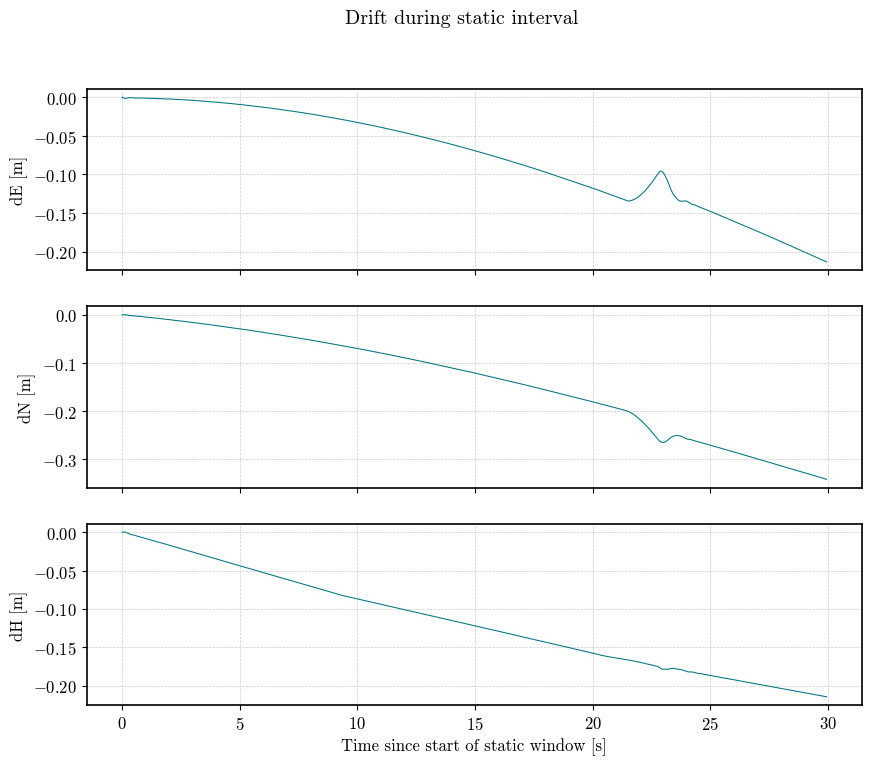

In [150]:
import matplotlib.pyplot as plt

# temps relatif
tr = t - t[0]

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(tr, x - x[0], label="Easting drift")
ax[0].set_ylabel("dE [m]")

ax[1].plot(tr, y - y[0], label="Northing drift")
ax[1].set_ylabel("dN [m]")

ax[2].plot(tr, z - z[0], label="Height drift")
ax[2].set_ylabel("dH [m]")
ax[2].set_xlabel("Time since start of static window [s]")

for a in ax:
    a.grid(True)

plt.suptitle("Drift during static interval")
plt.show()

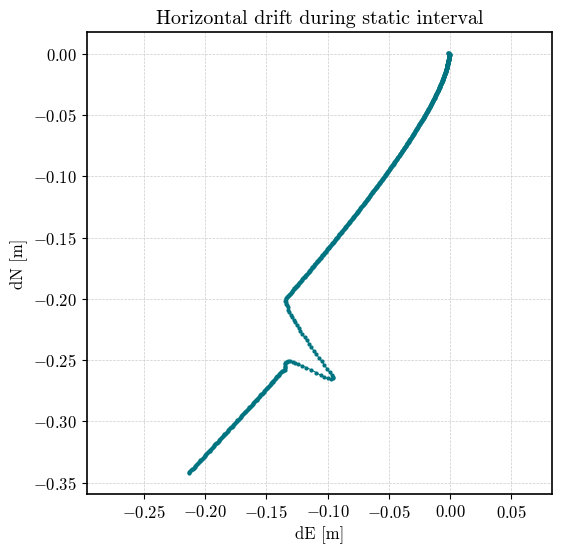

In [151]:
plt.figure(figsize=(6, 6))
plt.plot(x - x[0], y - y[0], "-o", markersize=2)
plt.xlabel("dE [m]")
plt.ylabel("dN [m]")
plt.title("Horizontal drift during static interval")
plt.axis("equal")
plt.grid(True)
plt.show()

In [4]:
from pyproj import Transformer
import numpy as np
import pandas as pd

ecef_to_lv95 = Transformer.from_crs("EPSG:4978", "EPSG:2056", always_xy=True)

def static_drift_stats(traj, t0=305380.0, t1=305430.0, label="traj"):
    mask = (traj.time >= t0) & (traj.time <= t1)
    t = traj.time[mask]
    ecef = traj.ecef[mask]

    if len(t) < 2:
        return {"label": label, "error": "not enough samples"}

    x, y, z = ecef_to_lv95.transform(ecef[:, 0], ecef[:, 1], ecef[:, 2])
    P = np.column_stack((x, y, z))
    P_mean = P.mean(axis=0)

    drift_vec = P[-1] - P[0]
    dist_to_mean_3d = np.linalg.norm(P - P_mean, axis=1)
    dist_to_mean_xy = np.linalg.norm(P[:, :2] - P_mean[:2], axis=1)

    dt = t[-1] - t[0]

    return {
        "label": label,
        "t_start": t[0],
        "t_end": t[-1],
        "duration_s": dt,
        "drift_3d_m": np.linalg.norm(drift_vec),
        "drift_xy_m": np.linalg.norm(drift_vec[:2]),
        "drift_z_m": drift_vec[2],
        "rmse_radius_3d_m": np.sqrt(np.mean(dist_to_mean_3d**2)),
        "max_radius_3d_m": dist_to_mean_3d.max(),
        "rmse_radius_xy_m": np.sqrt(np.mean(dist_to_mean_xy**2)),
        "max_radius_xy_m": dist_to_mean_xy.max(),
    }

In [9]:
import yaml
from lib.trajectory import load_trajectory

yaml_path = "/home/b085164/PDM_Romain_Defferrard/navtools/configs/compareCalibOutage.yml"

with open(yaml_path, "r") as f:
    cfg = yaml.safe_load(f)
reference_traj = load_trajectory(cfg["reference"])
target_trajs = [load_trajectory(tr) for tr in cfg["targets"]]
traj_map = {d["label"]: trj for d, trj in zip(cfg["targets"], target_trajs)}

traj_gnss = traj_map["ODyN | INS/GNSS"]
traj_corr = traj_map["ODyN | VUX+PUCK chunks"]

rows = []
rows.append(static_drift_stats(traj_gnss, t0=305380.0, t1=305430.0, label="ODyN | INS/GNSS"))
rows.append(static_drift_stats(traj_corr, t0=305380.0, t1=305430.0, label="ODyN | VUX+PUCK"))

df_static = pd.DataFrame(rows)
display(df_static)

Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage/ref_full_GNSS/reference.out
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage/outage_GNSS/out/ODyN.tar.gz
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage/chunks_VUX/out/ODyN.tar.gz
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage/chunks_VUX_PUCK/out/ODyN.tar.gz


,label,t_start,t_end,duration_s,drift_3d_m,drift_xy_m,drift_z_m,rmse_radius_3d_m,max_radius_3d_m,rmse_radius_xy_m,max_radius_xy_m
0,ODyN | INS/GNSS,305380.00356,305429.95348,49.94992,21.207104,21.194837,-0.721222,7.455720,16.312191,7.452952,16.303457
1,ODyN | VUX+PUCK,305380.00356,305429.95348,49.94992,21.314255,21.298415,-0.821558,7.487203,16.341492,7.483577,16.330195


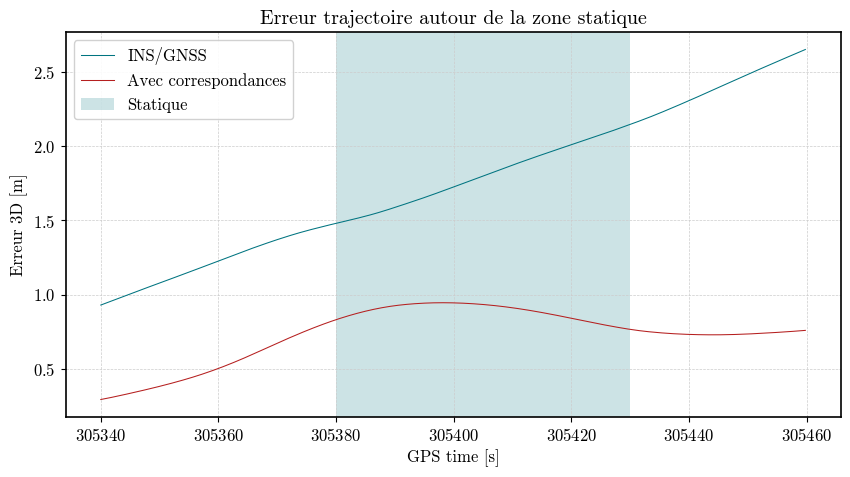

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer

ecef_to_lv95 = Transformer.from_crs("EPSG:4978", "EPSG:2056", always_xy=True)

def interp_ecef_on_grid(traj, t_grid):
    ecef_interp = np.zeros((len(t_grid), 3))
    for i in range(3):
        ecef_interp[:, i] = np.interp(t_grid, traj.time, traj.ecef[:, i])
    return ecef_interp

def ecef_to_map_xyz(ecef):
    x, y, z = ecef_to_lv95.transform(ecef[:, 0], ecef[:, 1], ecef[:, 2])
    return np.column_stack((x, y, z))

# fenêtre à analyser
t0 = 305340
t1 = 305460
dt = 0.2   # 5 Hz

t_grid = np.arange(t0, t1, dt)

ref_ecef  = interp_ecef_on_grid(reference_traj, t_grid)
gnss_ecef = interp_ecef_on_grid(traj_gnss, t_grid)
corr_ecef = interp_ecef_on_grid(traj_corr, t_grid)

ref_map  = ecef_to_map_xyz(ref_ecef)
gnss_map = ecef_to_map_xyz(gnss_ecef)
corr_map = ecef_to_map_xyz(corr_ecef)

err_gnss = np.linalg.norm(gnss_map - ref_map, axis=1)
err_corr = np.linalg.norm(corr_map - ref_map, axis=1)

plt.figure(figsize=(10,5))
plt.plot(t_grid, err_gnss, label="INS/GNSS")
plt.plot(t_grid, err_corr, label="Avec correspondances")
plt.axvspan(305380, 305430, alpha=0.2, label="Statique")
plt.xlabel("GPS time [s]")
plt.ylabel("Erreur 3D [m]")
plt.title("Erreur trajectoire autour de la zone statique")
plt.grid(True)
plt.legend()
plt.show()